In [8]:
import sys, os, json
from tqdm import tqdm
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns, scanpy as sc
sys.path.append('../../../')

from polygene.model.model import load_trained_model
from polygene.data_utils.tokenization import normalise_str

data_path =  "/media/rohola/ssd_storage/lung_cancer_atlas/"
neural_network_path = "/media/lleger/LaCie/mit/runs/polygene_unit_sphere/"

model, tokenizer = load_trained_model(neural_network_path, checkpoint_n=-1)

embedding_weights = W = model.embeddings.token_value_embeddings.weight
temperature = tau = model.temperature

normal_index = tokenizer.flattened_tokens.index(normalise_str('normal'))
disease_indices = [tokenizer.flattened_tokens.index(normalise_str(disease_label)) for disease_label in tokenizer.phenotypic_tokens_map["disease"][:10]
                if disease_label != normalise_str("normal")]


loading checkpoint-1500000


In [9]:
W.shape

torch.Size([1107, 240])

In [ ]:
# to draw a fresque of the latent space.
# we can start with the average normal representation of a cell. z0



from torch.nn.functional import softmax
@torch.no_grad()
def riemannian_metric(z, W, tau, temperature = 1):
    p = softmax((W @ z) / tau / temperature, dim=0)
    w_tau = (W / tau)
    fisher_information_metric = torch.diag(p) - torch.outer(p, p)
    return w_tau.T @ fisher_information_metric @ w_tau


n_timepoints = 1000
update_rate = 1e-2
normal_embedding = embedding_weights[normal_index].detach().cpu().numpy()

integral_paths = {}

from torch.nn.functional import softmax
import torch
probability_distribution = lambda z: softmax((W @ (z/z.norm())) / tau, dim=0)

for idx in tqdm(disease_indices):
    integral_paths[idx] = []
    z = torch.tensor(normal_embedding, dtype=torch.float32, device=model.device).requires_grad_(True)
    for n in range(n_timepoints):
        integral_paths[idx].append(z.detach().cpu().numpy())
        p_y = probability_distribution(z)[idx]
        p_y.backward()
        if p_y.item() > 0.9999999:
            break
        gradient_z = z.grad.detach().cpu().numpy()
        grad = z.grad if n > n_timepoints//2 else z.grad / z.grad.norm()
        z = (z + update_rate * grad).detach()
        z = z / z.norm()
        z.requires_grad_(True)


100%|██████████| 9/9 [00:00<00:00, 28.51it/s]


In [ ]:
# to draw a fresque of the latent space.
# we can start with the average normal representation of a cell. z0



from torch.nn.functional import softmax
@torch.no_grad()
def riemannian_metric(z, W, tau, temperature = 1):
    p = softmax((W @ z) / tau / temperature, dim=0)
    w_tau = (W / tau)
    fisher_information_metric = torch.diag(p) - torch.outer(p, p)
    return w_tau.T @ fisher_information_metric @ w_tau


n_timepoints = 1000
update_rate = 1e-2
normal_embedding = embedding_weights[normal_index].detach().cpu().numpy()

integral_paths = {}

from torch.nn.functional import softmax
import torch
probability_distribution = lambda z: softmax((W @ (z/z.norm())) / tau, dim=0)

for idx in tqdm(disease_indices):
    integral_paths[idx] = []
    z = torch.tensor(normal_embedding, dtype=torch.float32, device=model.device).requires_grad_(True)
    for n in range(n_timepoints):
        integral_paths[idx].append(z.detach().cpu().numpy())
        p_y = probability_distribution(z)[idx]
        p_y.backward()
        if p_y.item() > 0.9999999:
            break
        gradient_z = z.grad.detach().cpu().numpy()
        grad = z.grad if n > n_timepoints//2 else z.grad / z.grad.norm()
        z = (z + update_rate * grad).detach()
        z = z / z.norm()
        z.requires_grad_(True)

from sklearn.decomposition import PCA

pca = PCA(n_components=2, whiten=True, svd_solver="full")

disease_representations = embedding_weights[disease_indices].detach().cpu().numpy()
integral_paths_joined = np.array(sum(list(integral_paths.values()), []))
print(disease_representations.shape, integral_paths_joined.shape)
pca.fit(np.concatenate([disease_representations, integral_paths_joined]))


(9, 240) (906, 240)


PCA(n_components=2, svd_solver='full', whiten=True)

[b_cell_acute_lymphoblastic_leukemia]
(100, 2)
[lewy_body_dementia]
(100, 2)
[parkinson_disease]
(101, 2)
[periodontitis]
(101, 2)
[gingivitis]
(101, 2)
[epilepsy]
(98, 2)
[digestive_system_disorder]
(107, 2)
[dementia]
(97, 2)
[nonpapillary_renal_cell_carcinoma]
(101, 2)


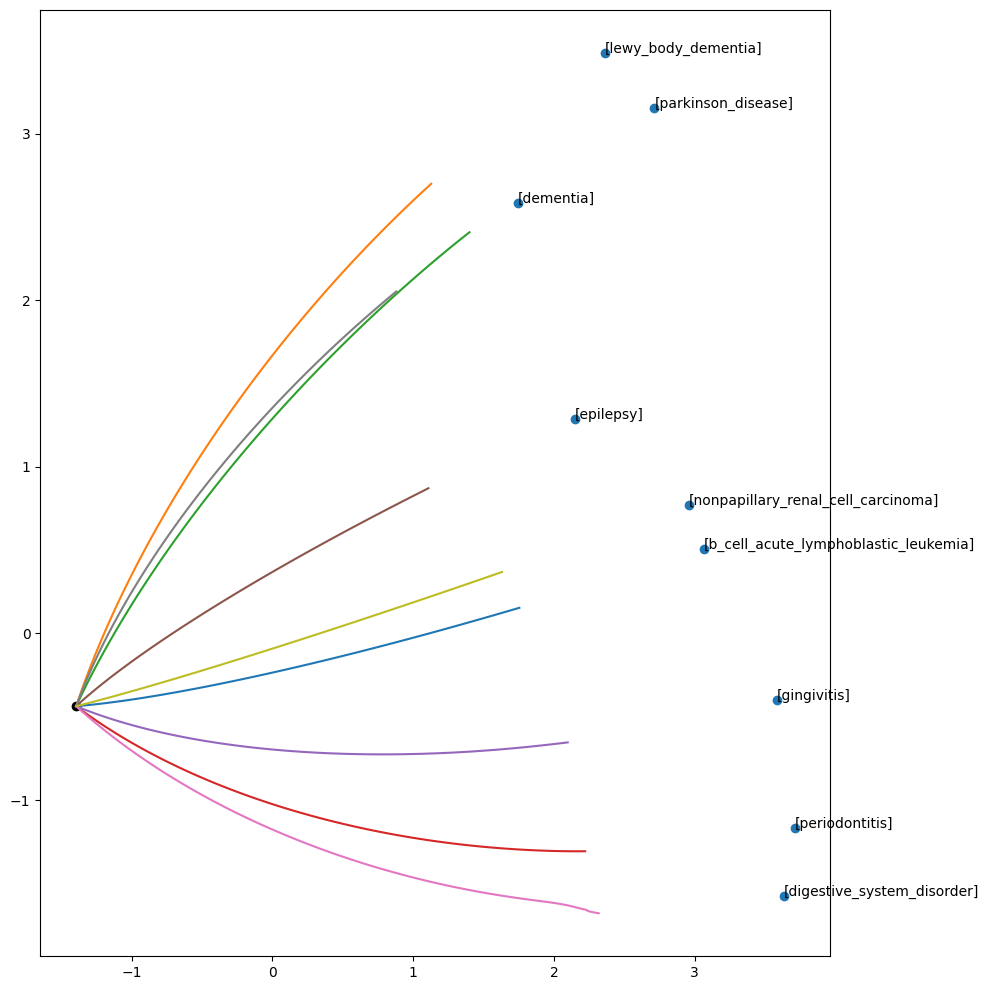

In [ ]:

# to draw a fresque of the latent space.
# we can start with the average normal representation of a cell. z0
import sys, os, json
from tqdm import tqdm
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns, scanpy as sc
sys.path.append('../../../')

from polygene.model.model import load_trained_model
from polygene.data_utils.tokenization import normalise_str

data_path =  "/media/rohola/ssd_storage/lung_cancer_atlas/"
neural_network_path = "/media/lleger/LaCie/mit/runs/polygene_unit_sphere/"

model, tokenizer = load_trained_model(neural_network_path, checkpoint_n=-1)

embedding_weights = W = model.embeddings.token_value_embeddings.weight
temperature = tau = model.temperature

normal_index = tokenizer.flattened_tokens.index(normalise_str('normal'))
disease_indices = [tokenizer.flattened_tokens.index(normalise_str(disease_label)) for disease_label in tokenizer.phenotypic_tokens_map["disease"][:10]
                if disease_label != normalise_str("normal")]



from torch.nn.functional import softmax
@torch.no_grad()
def riemannian_metric(z, W, tau, temperature = 1):
    p = softmax((W @ z) / tau / temperature, dim=0)
    w_tau = (W / tau)
    fisher_information_metric = torch.diag(p) - torch.outer(p, p)
    return w_tau.T @ fisher_information_metric @ w_tau


n_timepoints = 1000
update_rate = 1e-2
normal_embedding = embedding_weights[normal_index].detach().cpu().numpy()

integral_paths = {}

from torch.nn.functional import softmax
import torch
probability_distribution = lambda z: softmax((W @ (z/z.norm())) / tau, dim=0)

for idx in tqdm(disease_indices):
    integral_paths[idx] = []
    z = torch.tensor(normal_embedding, dtype=torch.float32, device=model.device).requires_grad_(True)
    for n in range(n_timepoints):
        integral_paths[idx].append(z.detach().cpu().numpy())
        p_y = probability_distribution(z)[idx]
        p_y.backward()
        if p_y.item() > 0.9999999:
            break
        gradient_z = z.grad.detach().cpu().numpy()
        grad = z.grad if n > n_timepoints//2 else z.grad / z.grad.norm()
        z = (z + update_rate * grad).detach()
        z = z / z.norm()
        z.requires_grad_(True)

from sklearn.decomposition import PCA

pca = PCA(n_components=2, whiten=True, svd_solver="full")

disease_representations = embedding_weights[disease_indices].detach().cpu().numpy()
integral_paths_joined = np.array(sum(list(integral_paths.values()), []))
print(disease_representations.shape, integral_paths_joined.shape)
pca.fit(np.concatenate([disease_representations, integral_paths_joined]))


fig, ax = plt.subplots(1,1, figsize=(10,10))

disease_pca = pca.transform(disease_representations)
names = [tokenizer.flattened_tokens[idx] for idx in disease_indices]
plt.scatter(disease_pca[:, 0], disease_pca[:, 1])
for index, name in enumerate(names):
    plt.annotate(name, (disease_pca[index, 0], disease_pca[index, 1]))

normal = pca.transform(normal_embedding.reshape(1, -1))
plt.scatter(normal[:, 0], normal[:, 1], color= "k")

for idx in integral_paths:
    print(tokenizer.flattened_tokens[idx])
    path_pca = pca.transform(integral_paths[idx])
    print(path_pca.shape)
    plt.plot(path_pca[:, 0], path_pca[:, 1])
    #break

plt.tight_layout()
plt.show()

loading checkpoint-1500000


100%|██████████| 29/29 [00:03<00:00,  9.53it/s]


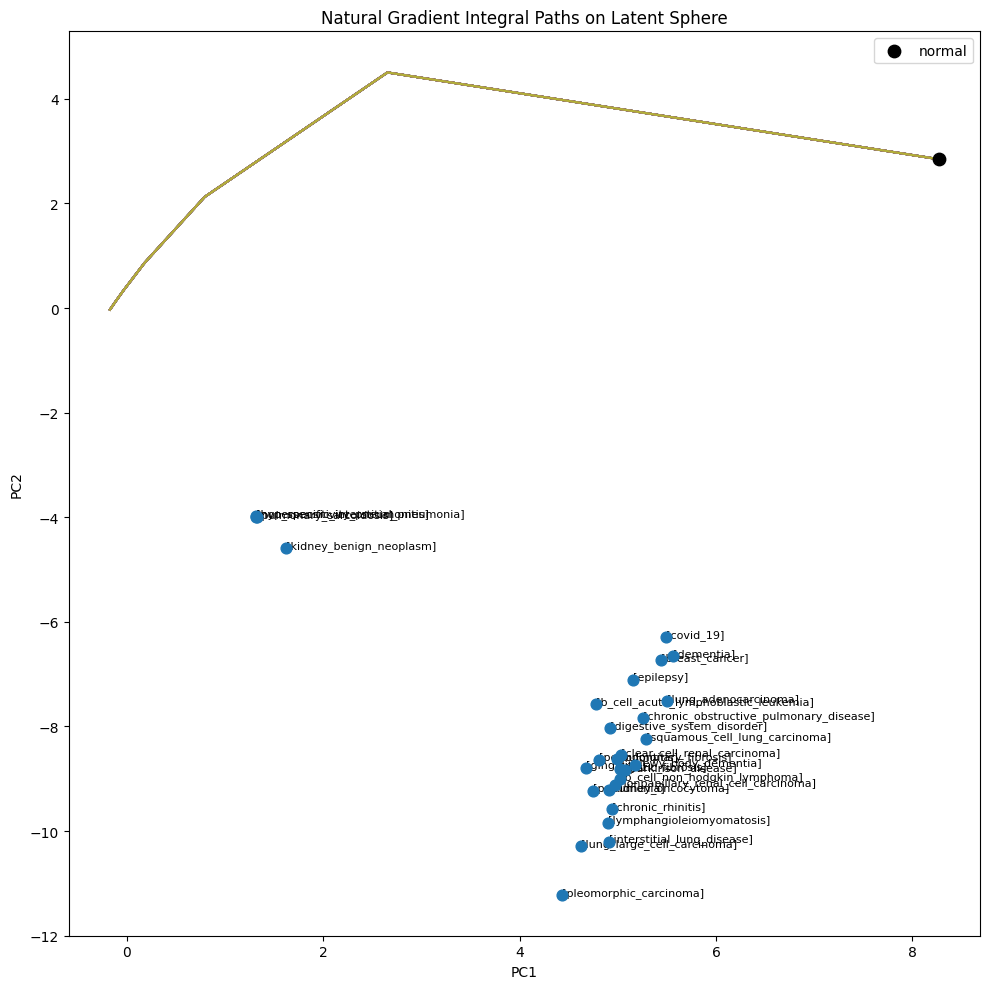

In [154]:
import sys, os, json
from tqdm import tqdm
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns, scanpy as sc
import torch
from torch.nn.functional import softmax
from sklearn.decomposition import PCA

sys.path.append('../../../')
from polygene.model.model import load_trained_model
from polygene.data_utils.tokenization import normalise_str

neural_network_path = "/media/lleger/LaCie/mit/runs/polygene_unit_sphere/"
model, tokenizer = load_trained_model(neural_network_path, checkpoint_n=-1)

embedding_weights = W = model.embeddings.token_value_embeddings.weight
temperature = tau = model.temperature

normal_index = tokenizer.flattened_tokens.index(normalise_str('normal'))
disease_indices = [tokenizer.flattened_tokens.index(normalise_str(disease_label))
                   for disease_label in tokenizer.phenotypic_tokens_map["disease"][:30]
                   if disease_label != normalise_str("normal")]

probability_distribution = lambda z: softmax((W @ (z / z.norm())) / tau, dim=0)
from torch.nn.functional import softmax
@torch.no_grad()
def riemannian_metric(z, W, tau, temperature = 2):
    p = softmax((W @ z) / tau / temperature, dim=0)
    w_tau = (W / tau)
    fisher_information_metric = torch.diag(p) - torch.outer(p, p)
    return w_tau.T @ fisher_information_metric @ w_tau

n_timepoints = 100
update_rate = 1e-1
normal_embedding = embedding_weights[normal_index].detach().cpu().numpy()
integral_paths = {}

for idx in tqdm(disease_indices):
    integral_paths[idx] = []
    z = torch.tensor(normal_embedding, dtype=torch.float32, device=model.device).requires_grad_(True)
    for n in range(n_timepoints):
        integral_paths[idx].append(z.detach().cpu().numpy())
        p_y = probability_distribution(z)[idx]
        p_y.backward()
        #if p_y.item() > 0.9999:
        #    break
        G = riemannian_metric(z.detach(), W, tau)
        natural_gradient = torch.linalg.solve(G, z.grad)
        #tangent = natural_gradient/natural_gradient.norm()# - (natural_gradient @ z.detach()) * z.detach()
        tangent = natural_gradient - (natural_gradient @ z.detach()) * z.detach()
        z = (z.detach() + update_rate )
        z = z / z.norm()
        z.requires_grad_(True)

pca = PCA(n_components=2, whiten=True, svd_solver="full")
disease_representations = embedding_weights[disease_indices].detach().cpu().numpy()
integral_paths_joined = np.concatenate(list(integral_paths.values()))
pca.fit(np.concatenate([disease_representations, integral_paths_joined]))
#pca.fit(np.concatenate([disease_representations]))

fig, ax = plt.subplots(1, 1, figsize=(10, 10))

disease_pca = pca.transform(disease_representations)
names = [tokenizer.flattened_tokens[idx] for idx in disease_indices]
ax.scatter(disease_pca[:, 0], disease_pca[:, 1], zorder=5, s=60)
for index, name in enumerate(names):
    ax.annotate(name, (disease_pca[index, 0], disease_pca[index, 1]), fontsize=8)

normal_pca = pca.transform(normal_embedding.reshape(1, -1))
ax.scatter(normal_pca[:, 0], normal_pca[:, 1], color="k", s=80, zorder=5, label="normal")

for idx in integral_paths:
    path_pca = pca.transform(np.array(integral_paths[idx]))
    ax.plot(path_pca[:, 0], path_pca[:, 1], linewidth=1.5, alpha=0.8)

ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_title("Natural Gradient Integral Paths on Latent Sphere")
ax.legend()
plt.tight_layout()
plt.savefig("fresque_natural_gradient.png", dpi=200, bbox_inches="tight")
plt.show()